# Brazo 2 — Forma: trazas de deformación del NIST

## Avance 1 — Análisis exploratorio de datos

**Equipo 39 · Proyecto Integrador MNA**

Este notebook analiza el segundo conjunto de **datos reales** del proyecto: perfiles de altura medidos con un interferómetro a lo largo de cuatro estructuras de los chips de referencia del NIST (RM 8096 de óxido y RM 8097 de polisilicio). Se puede ejecutar completo de principio a fin (*Run All*) desde el repositorio: lee los archivos originales de `datos/nist/crudos/` y usa las funciones de `src/pinn_mems/nist/brazo2.py`.

**En tres frases:**
1. El NIST publica las trazas originales de dos vigas biempotradas (para medir la **deformación residual**) y dos voladizos curvados (para medir el **gradiente de deformación**).
2. Aquí se cargan y calibran esas trazas, se describen sus características con un análisis exploratorio y después se compara cada perfil con el modelo que ajusta el propio NIST.
3. Los residuos resultan **mayores que el ruido de medición y con estructura**: es el tipo de discrepancia entre modelo y medición que el proyecto quiere tratar con datos reales.

### Contenido
- [Preparación: entorno y carga de las trazas](#Preparación)
- [1. Estructura y comprensión de los datos](#1.-Estructura-y-comprensión-de-los-datos)
- [2. Análisis univariante](#2.-Análisis-univariante)
- [3. Análisis bi/multivariante](#3.-Análisis-bi/multivariante)
- [4. Aspectos del EDA que no aplican al conjunto de datos](#4.-Aspectos-del-EDA-que-no-aplican-al-conjunto-de-datos)
- [5. Análisis por perfil para el Brazo 2](#5.-Análisis-por-perfil-para-el-Brazo-2)
- [6. Conclusiones](#6.-Conclusiones)

### Objetivos del análisis

Los objetivos principales son:

- describir la estructura y características de los datos;
- identificar valores faltantes y posibles valores atípicos;
- analizar las distribuciones de las variables;
- estudiar la relación entre posición y deflexión;
- comparar comportamientos entre materiales y tipos de ensayo;
- justificar las operaciones de preprocesamiento aplicadas;
- establecer conclusiones relevantes derivadas del EDA.

## Preparación

El notebook lee las trazas desde la carpeta `datos/nist/crudos/` del propio repositorio, así que debe abrirse desde el repositorio. Las funciones de carga y de detección de atípicos están en `src/pinn_mems/nist/brazo2.py`, con pruebas en `tests/test_brazo2.py`.

In [1]:
import sys
from pathlib import Path

# Busca la raíz del repositorio subiendo desde la carpeta actual
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "pinn_mems").is_dir())
sys.path.insert(0, str(RAIZ / "src"))

## Librerías

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pinn_mems.nist.archivos import verificar_integridad
from pinn_mems.nist.brazo2 import DATA_DIR, detect_iqr_outliers, load_all_traces

## Estandarización de formatos

In [3]:
# Evita repetir tamaños y formatos por todo el notebook.
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

FIGSIZE = (10, 6)

## Extracción de archivos

In [4]:
excel_files = sorted(DATA_DIR.glob("*STRAIN*.xlsx"))

print(f"Archivos encontrados: {len(excel_files)}")
for file_path in excel_files:
    print(file_path.name)

# Los archivos crudos no deben haberse modificado desde su descarga
integridad = verificar_integridad(DATA_DIR)
print(f"\nArchivos que coinciden con SHA256SUMS: {sum(integridad.values())} de {len(integridad)}")

Archivos encontrados: 10
RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0009.L200.Ins3.y.126.72.xlsx
RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8097.0108.P2.0deg.L500.Ins3.y.239.421.xlsx
RESIDUAL.STRAIN.Sample.Data.Trace.b.RM.8096.0009.L200.Ins3.xlsx
RESIDUAL.STRAIN.Sample.Data.Trace.b.RM.8097.0108.P2.0deg.L500.Ins3.xlsx
RESIDUAL.STRAIN.Sample.Data.Trace.e.RM.8097.0108.P2.0deg.L500.Ins3.y.174.659.xlsx
STRAIN.GRADIENT.Sample.Data.Trace.a.RM.8097.0103.P2.180deg.L650.Ins3.y.818.347.xlsx
STRAIN.GRADIENT.Sample.Data.Trace.c.RM.8097.0103.P2.180deg.L650.Ins3.xlsx
STRAIN.GRADIENT.Sample.Data.Trace.d.RM.8096.0001.L200.Ins3.xlsx
STRAIN.GRADIENT.Sample.Data.Trace.e.RM.8096.0001.L200.Ins3.y.16.58.xlsx
STRAIN.GRADIENT.Sample.Data.Trace.e.RM.8097.0103.P2.180deg.L650.Ins3.y.757.511.xlsx

Archivos que coinciden con SHA256SUMS: 10 de 10


## Funciones para cargar las trazas

Las funciones están en `src/pinn_mems/nist/brazo2.py`:

- `get_trace_metadata` obtiene del nombre del archivo el tipo de ensayo, la estructura (viga biempotrada para *Residual Strain* y voladizo para *Strain Gradient*), el material, el chip, la longitud y la traza.
- `load_trace` lee una traza en micrómetros: cuando la hoja trae una columna de x en mm y otra en µm, usa la de µm. Si la hoja incluye los **factores de calibración** del instrumento (`calx` y `calz`, presentes en las trazas b, c y d), devuelve x·calx y z·calz y marca la traza como calibrada. Las trazas transversales (a, a', e) no traen esos factores y se conservan sin calibrar.
- `load_all_traces` construye el dataset maestro con todas las trazas.

In [5]:
def get_trace_metadata(file_path):
    """Extract metadata from a NIST trace filename."""
    filename = file_path.name
    filename_upper = filename.upper()

    test_type = (
        "Residual Strain"
        if "RESIDUAL.STRAIN" in filename_upper
        else "Strain Gradient"
    )

    material = "RM 8096" if "RM.8096" in filename_upper else "RM 8097"

    trace_section = filename.split("Trace.")[1]
    trace = trace_section.split(".RM.")[0]

    return {
        "test_type": test_type,
        "material": material,
        "trace": trace,
        "file": filename,
    }


def load_trace(file_path):
    """Load x and z measurements from a NIST Excel trace in micrometers."""
    df = pd.read_excel(file_path)
    metadata = get_trace_metadata(file_path)

    x_columns = [
        column
        for column in df.columns
        if isinstance(column, str)
        and column.strip().startswith(("x-uncal", "x (uncal)"))
    ]

    z_columns = [
        column
        for column in df.columns
        if isinstance(column, str)
        and column.strip().startswith(("z-uncal", "z (uncal)"))
    ]

    x_column = None

    for column in x_columns:
        units = str(df[column].iloc[1]).strip().lower()

        if units == "um":
            x_column = column
            break

    if x_column is None and x_columns:
        x_column = x_columns[0]

    z_column = z_columns[0] if z_columns else None

    if x_column is None or z_column is None:
        raise ValueError(
            f"No se encontraron columnas x/z válidas en {file_path.name}"
        )

    trace_df = df[[x_column, z_column]].copy()
    trace_df.columns = ["x", "z"]

    trace_df["x"] = pd.to_numeric(trace_df["x"], errors="coerce")
    trace_df["z"] = pd.to_numeric(trace_df["z"], errors="coerce")

    trace_df = trace_df.dropna(subset=["x", "z"]).reset_index(drop=True)

    for column, value in metadata.items():
        trace_df[column] = value

    return trace_df

## Construir Dataset Maestro

In [6]:
df_master = load_all_traces()

> Observaciones aportadas por cada archivo

In [7]:
trace_summary = (
    df_master
    .groupby(
        ["test_type", "material", "trace", "file"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "observations"})
)

display(trace_summary)

,test_type,material,trace,file,observations
0,Residual Strain,RM 8096,ap,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...,144
1,Residual Strain,RM 8096,b,RESIDUAL.STRAIN.Sample.Data.Trace.b.RM.8096.00...,640
2,Residual Strain,RM 8097,ap,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8097.0...,413
3,Residual Strain,RM 8097,b,RESIDUAL.STRAIN.Sample.Data.Trace.b.RM.8097.01...,640
4,Residual Strain,RM 8097,e,RESIDUAL.STRAIN.Sample.Data.Trace.e.RM.8097.01...,412
5,Strain Gradient,RM 8096,d,STRAIN.GRADIENT.Sample.Data.Trace.d.RM.8096.00...,427
6,Strain Gradient,RM 8096,e,STRAIN.GRADIENT.Sample.Data.Trace.e.RM.8096.00...,56
7,Strain Gradient,RM 8097,a,STRAIN.GRADIENT.Sample.Data.Trace.a.RM.8097.01...,304
8,Strain Gradient,RM 8097,c,STRAIN.GRADIENT.Sample.Data.Trace.c.RM.8097.01...,623
9,Strain Gradient,RM 8097,e,STRAIN.GRADIENT.Sample.Data.Trace.e.RM.8097.01...,303


## 1. Estructura y comprensión de los datos

En esta sección se analiza la estructura general del conjunto de datos, incluyendo
el número de observaciones y variables, los tipos de datos, las variables
categóricas y numéricas, así como la presencia de valores faltantes.

El conjunto de datos se construyó a partir de las trazas experimentales de
Residual Strain y Strain Gradient correspondientes a los materiales de referencia
RM 8096 y RM 8097.

### Dimensiones y tipos de variables

In [8]:
print(f"Número de observaciones: {df_master.shape[0]:,}")
print(f"Número de variables: {df_master.shape[1]}")

display(
    pd.DataFrame({
        "data_type": df_master.dtypes,
        "non_null": df_master.notna().sum(),
        "null": df_master.isna().sum(),
        "unique": df_master.nunique(),
    })
)

Número de observaciones: 3,962
Número de variables: 10


,data_type,non_null,null,unique
test_type,str,3962,0,2
structure,str,3962,0,2
material,str,3962,0,2
chip,str,3962,0,4
length_um,int64,3962,0,3
trace,str,3962,0,6
x,float64,3962,0,2759
z,float64,3962,0,3958
calibrated,bool,3962,0,2
file,str,3962,0,10


#### Descripción de las variables

El conjunto de datos consolidado contiene las siguientes variables:

- **test_type:** tipo de análisis realizado sobre la muestra, correspondiente a
  `Residual Strain` o `Strain Gradient`.
- **structure:** tipo de estructura medida: `fixed-fixed` (viga biempotrada,
  en Residual Strain) o `cantilever` (voladizo, en Strain Gradient).
- **material:** material de referencia analizado (`RM 8096` o `RM 8097`).
- **chip:** identificador del chip dentro del material de referencia.
- **length_um:** longitud nominal de la estructura en micrómetros (µm).
- **trace:** identificador de la traza de medición.
- **x:** posición horizontal de la medición en micrómetros (µm).
- **z:** desplazamiento o perfil vertical medido en micrómetros (µm).
- **calibrated:** indica si a x y z se les aplicaron los factores de
  calibración incluidos en el archivo.
- **file:** archivo de origen de cada observación.

Las variables `x`, `z` y `length_um` son cuantitativas, `calibrated` es booleana
y `test_type`, `structure`, `material`, `chip`, `trace` y `file` son categóricas.

### Estadística descriptiva

In [9]:
numeric_summary = (
    df_master[["x", "z"]]
    .describe()
    .T
)

numeric_summary["range"] = (
    numeric_summary["max"] - numeric_summary["min"]
)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,range
x,3962.0000,94.4052,611.0064,-1265.0001,-156.0540,97.5971,310.0690,1265.0001,2530.0003
z,3962.0000,0.7195,2.2311,-5.8574,-0.6462,-0.0479,1.7240,19.0176,24.8749


### Cardinalidad de las categóricas

In [10]:
categorical_columns = [
    "test_type",
    "material",
    "trace",
]

for column in categorical_columns:
    print(f"\n{column}")
    display(
        df_master[column]
        .value_counts()
        .rename_axis(column)
        .reset_index(name="count")
    )


test_type


,test_type,count
0,Residual Strain,2249
1,Strain Gradient,1713



material


,material,count
0,RM 8097,2695
1,RM 8096,1267



trace


,trace,count
0,b,1280
1,e,771
2,c,623
3,ap,557
4,d,427
5,a,304


### Estadísticas por traza

In [11]:
trace_statistics = (
    df_master
    .groupby(
        ["test_type", "material", "trace"],
        as_index=False,
    )
    .agg(
        observations=("z", "size"),
        x_min=("x", "min"),
        x_max=("x", "max"),
        z_mean=("z", "mean"),
        z_std=("z", "std"),
        z_min=("z", "min"),
        z_max=("z", "max"),
    )
)

display(trace_statistics)

,test_type,material,trace,observations,x_min,x_max,z_mean,z_std,z_min,z_max
0,Residual Strain,RM 8096,ap,144,0.0000,252.2610,-0.5635,0.7809,-2.9809,0.1456
1,Residual Strain,RM 8096,b,640,0.0000,253.0001,1.6543,2.3432,-2.1788,5.3275
2,Residual Strain,RM 8097,ap,413,0.0000,1254.0100,0.0979,1.3635,-0.7730,3.0006
3,Residual Strain,RM 8097,b,640,0.0000,1265.0001,0.4780,1.3613,-0.7727,4.7550
4,Residual Strain,RM 8097,e,412,0.0000,1254.0100,0.2117,1.6208,-0.7961,4.2236
5,Strain Gradient,RM 8096,d,427,0.0000,252.2078,2.8374,4.0507,-4.1210,19.0176
6,Strain Gradient,RM 8096,e,56,0.0000,252.2610,-1.1525,2.0418,-5.8574,0.0713
7,Strain Gradient,RM 8097,a,304,-1254.0100,0.0000,0.0634,1.1048,-0.7511,2.9656
8,Strain Gradient,RM 8097,c,623,-1265.0001,0.0000,0.3093,1.3869,-2.6045,4.7425
9,Strain Gradient,RM 8097,e,303,-1254.0100,0.0000,0.2658,1.6243,-0.7034,4.8358


### Validación de la carga de datos

Antes de realizar el análisis exploratorio, se verifica que las variables
numéricas hayan sido interpretadas correctamente desde los archivos originales.
Esta validación es especialmente importante debido a que los archivos Excel
contienen información adicional, fórmulas y estructuras que no corresponden
exclusivamente a las mediciones experimentales.

In [12]:
for file_path in excel_files:
    df_raw = pd.read_excel(file_path)

    print("\n" + "=" * 80)
    print(file_path.name)
    print("Shape original:", df_raw.shape)
    print("Columnas:", list(df_raw.columns))

    display(df_raw.iloc[:8, :3])


RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0009.L200.Ins3.y.126.72.xlsx
Shape original: (642, 13)
Columnas: ['x-uncal', 'z-uncal', 'z-uncal.1', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', datetime.datetime(2012, 4, 30, 0, 0)]


,x-uncal,z-uncal,z-uncal.1
0,NaN,,
1,um,um,um
2,0,-0.0041,-0.0041
3,0.3948,-0.0110,-0.0110
4,0.7895,-0.0085,-0.0085
5,1.1843,0.0038,0.0038
6,1.5791,0.0044,0.0044
7,1.9739,-0.0068,-0.0068



RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8097.0108.P2.0deg.L500.Ins3.y.239.421.xlsx
Shape original: (642, 13)
Columnas: ['x-uncal', 'x-uncal.1', 'z-uncal', 'z-uncal.1', 'Unnamed: 4', "RM 8097 - RESIDUAL STRAIN (Trace a', a, e, or e')", 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', datetime.datetime(2012, 4, 30, 0, 0)]


,x-uncal,x-uncal.1,z-uncal
0,NaN,NaN,
1,mm,um,um
2,0,0,-0.6271
3,0.0020,1.9625,-0.6336
4,0.0039,3.9249,-0.6296
5,0.0059,5.8874,-0.6277
6,0.0078,7.8498,-0.6304
7,0.0098,9.8123,-0.6325



RESIDUAL.STRAIN.Sample.Data.Trace.b.RM.8096.0009.L200.Ins3.xlsx
Shape original: (642, 16)
Columnas: ['x (uncal)', 'z (uncal)', 'z (uncal).1', 'calx =', 'calz =', 'Unnamed: 5', 'Unnamed: 6', 'AF =', 2.91104, 'x1F =', 30.0029, 30.090808497000005, 30.090760467934043, 'Unnamed: 13', 'Unnamed: 14', datetime.datetime(2012, 4, 30, 0, 0)]


...

,x (uncal),z (uncal),calx =
0,NaN,,1.0029
1,um,um,f=
2,0,-1.3407,α (in radians)=
3,0.3948,-1.3038,NaN
4,0.7895,-1.2002,NaN
5,1.1843,-1.1324,NaN
6,1.5791,-1.2259,v-axis data
7,1.9739,-1.1029,NaN



STRAIN.GRADIENT.Sample.Data.Trace.e.RM.8096.0001.L200.Ins3.y.16.58.xlsx
Shape original: (642, 13)
Columnas: ['x-uncal', 'z-uncal', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', datetime.datetime(2012, 5, 14, 0, 0)]


,x-uncal,z-uncal,Unnamed: 2
0,NaN,,NaN
1,um,um,NaN
2,0,0.0713,NaN
3,0.3948,0.0589,NaN
4,0.7895,0.0420,NaN
5,1.1843,0.0217,NaN
6,1.5791,0.0060,NaN
7,1.9739,-0.0043,NaN



STRAIN.GRADIENT.Sample.Data.Trace.e.RM.8097.0103.P2.180deg.L650.Ins3.y.757.511.xlsx
Shape original: (642, 13)
Columnas: ['x-uncal', 'x-uncal.1', 'z-uncal', 'z-uncal.1', 'Unnamed: 4', 'RM  8097 - STRAIN GRADIENT (Trace a or e, another possibility)', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', datetime.datetime(2012, 5, 14, 0, 0)]


,x-uncal,x-uncal.1,z-uncal
0,NaN,NaN,
1,mm,um,um
2,0,0,0.0802
3,0.0020,-1.9625,0.0800
4,0.0039,-3.9249,0.0816
5,0.0059,-5.8874,0.0850
6,0.0078,-7.8498,0.0870
7,0.0098,-9.8123,0.0869


## 2. Análisis univariante

En esta sección se estudia individualmente la distribución de las variables
cuantitativas `x` y `z`, así como la frecuencia de las variables categóricas.

Se utilizan estadísticas descriptivas, histogramas y diagramas de caja para
identificar características de las distribuciones, dispersión, asimetría y
posibles valores atípicos.

### Asimetria

In [13]:
skewness = (
    df_master[["x", "z"]]
    .skew()
    .rename("skewness")
    .to_frame()
)

display(skewness)

,skewness
x,-0.2301
z,2.3442


### Histogramas de x y z

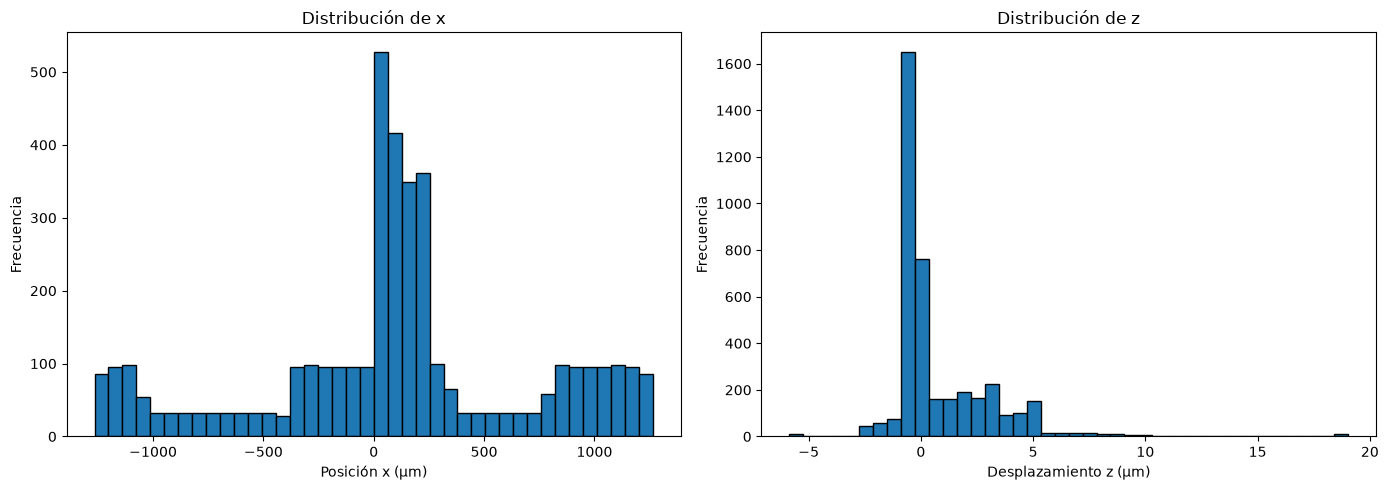

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df_master["x"],
    bins=40,
    edgecolor="black",
)
axes[0].set_title("Distribución de x")
axes[0].set_xlabel("Posición x (µm)")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(
    df_master["z"],
    bins=40,
    edgecolor="black",
)
axes[1].set_title("Distribución de z")
axes[1].set_xlabel("Desplazamiento z (µm)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Boxplot

/tmp/ipykernel_65728/1266320552.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(
/tmp/ipykernel_65728/1266320552.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


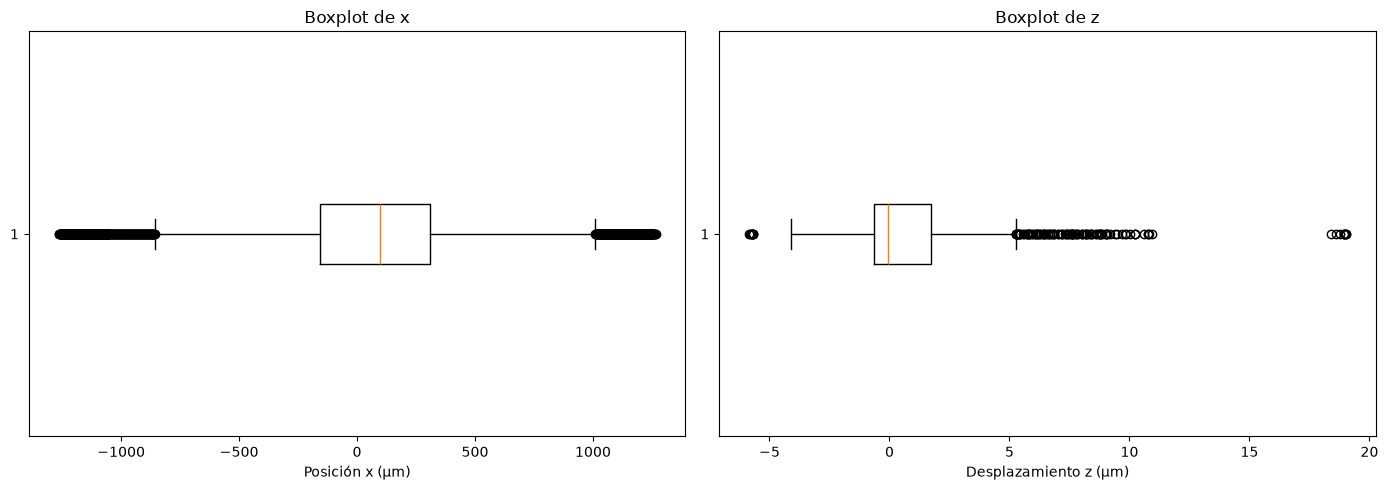

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    df_master["x"],
    vert=False,
)
axes[0].set_title("Boxplot de x")
axes[0].set_xlabel("Posición x (µm)")

axes[1].boxplot(
    df_master["z"],
    vert=False,
)
axes[1].set_title("Boxplot de z")
axes[1].set_xlabel("Desplazamiento z (µm)")

plt.tight_layout()
plt.show()

### Interpretación del análisis univariante

La variable `x` presenta una asimetría global de -0.2301, lo que indica una
asimetría negativa ligera. Sin embargo, su distribución global es multimodal
debido a que el conjunto consolida trazas con diferentes rangos espaciales y
orientaciones. Por esta razón, la distribución global de `x` no debe
interpretarse como una única población ni requiere una transformación para
aproximarla a una distribución normal.

La variable `z` presenta una asimetría positiva considerable (2.3442). El
histograma y el diagrama de caja muestran una concentración importante de
observaciones alrededor de valores cercanos a cero y una cola hacia valores
positivos elevados.

Los diagramas de caja identifican observaciones potencialmente atípicas,
especialmente en `z`. No obstante, estas observaciones no se eliminan
automáticamente, ya que pueden corresponder a características reales de las
trazas experimentales. Su comportamiento se analizará por traza antes de
determinar si requieren algún tratamiento.

### Detección formal de atípicos

In [16]:
outlier_summary = (
    df_master
    .groupby(
        ["test_type", "material", "trace"],
    )
    .apply(
        detect_iqr_outliers,
        include_groups=False,
    )
    .reset_index()
)

display(outlier_summary)

,test_type,material,trace,q1,q3,iqr,lower_bound,upper_bound,outliers,outlier_percentage
0,Residual Strain,RM 8096,ap,-0.8579,-0.0046,0.8534,-2.1380,1.2755,16.0000,11.1111
1,Residual Strain,RM 8096,b,-0.5173,3.9624,4.4796,-7.2367,10.6818,0.0000,0.0000
2,Residual Strain,RM 8097,ap,-0.7119,0.0014,0.7133,-1.7818,1.0713,77.0000,18.6441
3,Residual Strain,RM 8097,b,-0.6647,1.3346,1.9993,-3.6637,4.3335,10.0000,1.5625
4,Residual Strain,RM 8097,e,-0.7168,0.0039,0.7208,-1.7980,1.0851,78.0000,18.9320
5,Strain Gradient,RM 8096,d,-0.3505,5.1356,5.4861,-8.5797,13.3647,9.0000,2.1077
6,Strain Gradient,RM 8096,e,-0.6626,-0.0272,0.6354,-1.6157,0.9260,9.0000,16.0714
7,Strain Gradient,RM 8097,a,-0.5038,-0.0059,0.4980,-1.2508,0.7411,39.0000,12.8289
8,Strain Gradient,RM 8097,c,-0.5191,1.4621,1.9812,-3.4909,4.4339,4.0000,0.6421
9,Strain Gradient,RM 8097,e,-0.5170,0.0147,0.5317,-1.3145,0.8121,41.0000,13.5314


In [17]:
outlier_records = []

for group_keys, group in df_master.groupby(
    ["test_type", "material", "trace"]
):
    q1 = group["z"].quantile(0.25)
    q3 = group["z"].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (group["z"] < lower_bound)
        | (group["z"] > upper_bound)
    )

    group_outliers = group.loc[mask].copy()

    if not group_outliers.empty:
        outlier_records.append(group_outliers)

if outlier_records:
    df_outliers = pd.concat(outlier_records, ignore_index=True)
else:
    df_outliers = pd.DataFrame(columns=df_master.columns)

print(f"Posibles valores atípicos: {len(df_outliers)}")
display(df_outliers.head(20))

Posibles valores atípicos: 283


,test_type,structure,material,chip,length_um,trace,x,z,calibrated,file
0,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,218.7050,-2.9809,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
1,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,219.1000,-2.8454,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
2,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,219.4950,-2.6947,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
3,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,219.8890,-2.5287,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
4,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,220.2840,-2.3968,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
5,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,220.6790,-2.3214,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
6,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,221.0740,-2.2847,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
7,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,221.4690,-2.2669,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
8,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,221.8630,-2.2687,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
9,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,222.2580,-2.2911,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...


### Resumen por trazas

In [18]:
outlier_counts = (
    df_outliers
    .groupby(
        ["test_type", "material", "trace"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "outliers"})
)

trace_sizes = (
    df_master
    .groupby(
        ["test_type", "material", "trace"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "observations"})
)

outlier_summary = trace_sizes.merge(
    outlier_counts,
    on=["test_type", "material", "trace"],
    how="left",
)

outlier_summary["outliers"] = (
    outlier_summary["outliers"]
    .fillna(0)
    .astype(int)
)

outlier_summary["outlier_percentage"] = (
    100
    * outlier_summary["outliers"]
    / outlier_summary["observations"]
)

display(outlier_summary)

,test_type,material,trace,observations,outliers,outlier_percentage
0,Residual Strain,RM 8096,ap,144,16,11.1111
1,Residual Strain,RM 8096,b,640,0,0.0000
2,Residual Strain,RM 8097,ap,413,77,18.6441
3,Residual Strain,RM 8097,b,640,10,1.5625
4,Residual Strain,RM 8097,e,412,78,18.9320
5,Strain Gradient,RM 8096,d,427,9,2.1077
6,Strain Gradient,RM 8096,e,56,9,16.0714
7,Strain Gradient,RM 8097,a,304,39,12.8289
8,Strain Gradient,RM 8097,c,623,4,0.6421
9,Strain Gradient,RM 8097,e,303,41,13.5314


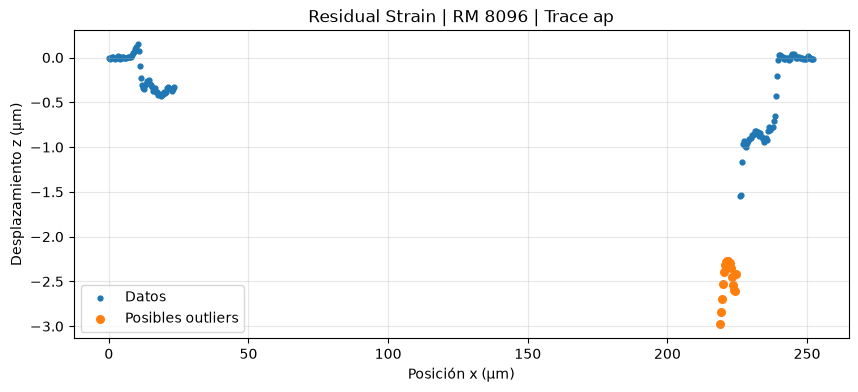

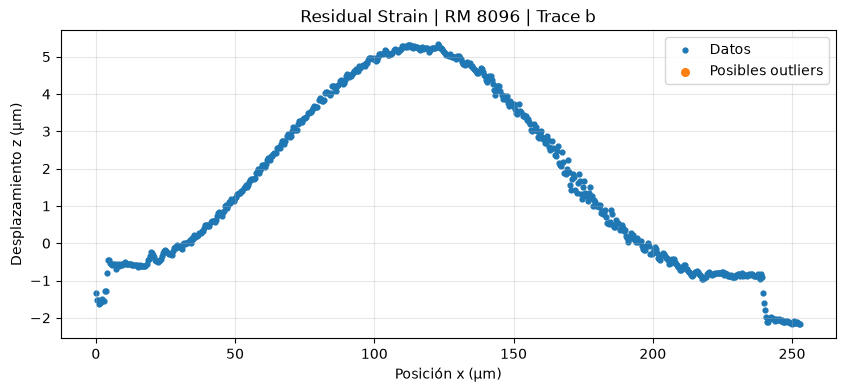

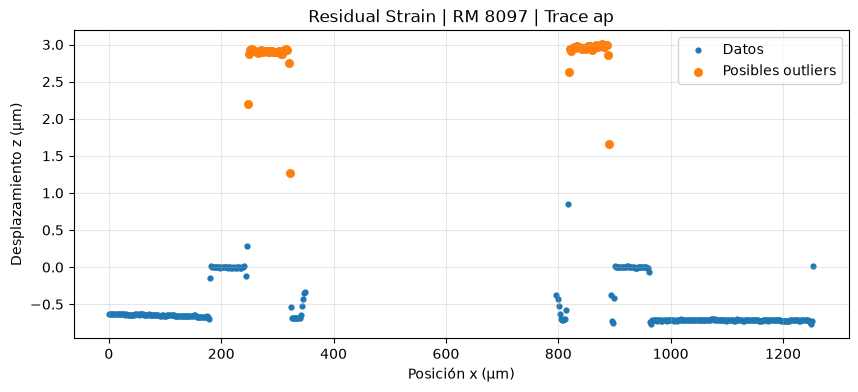

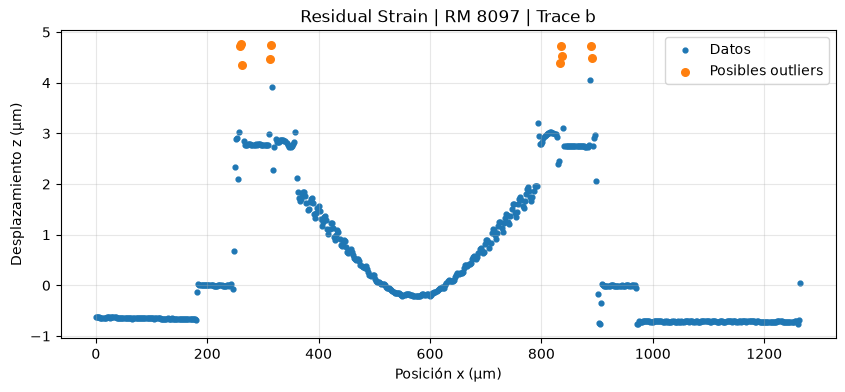

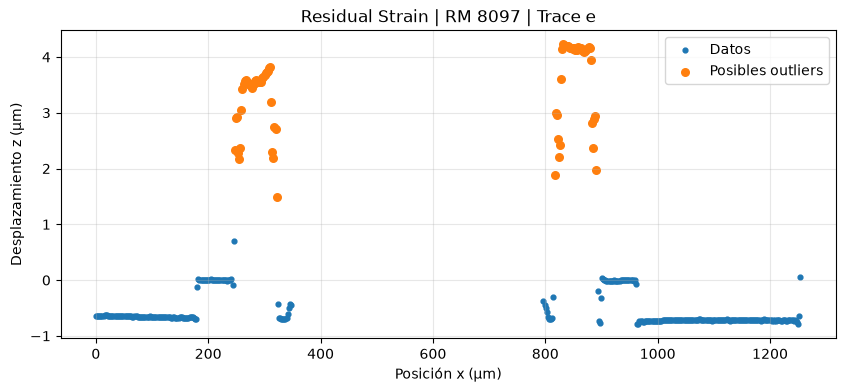

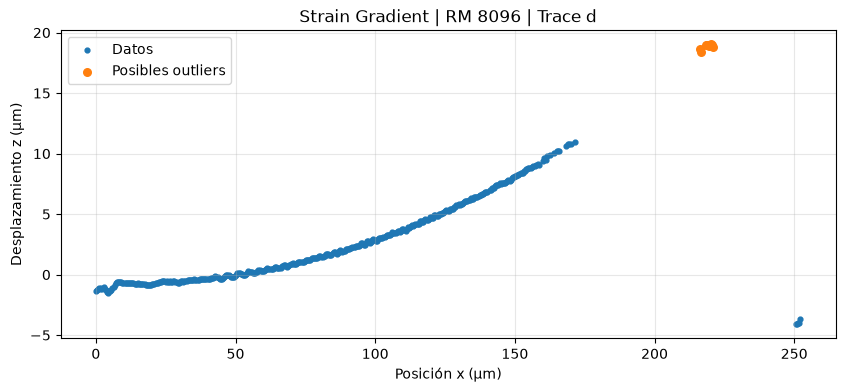

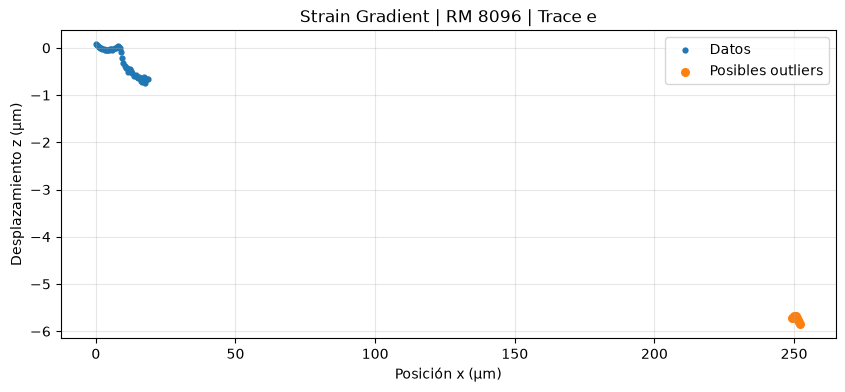

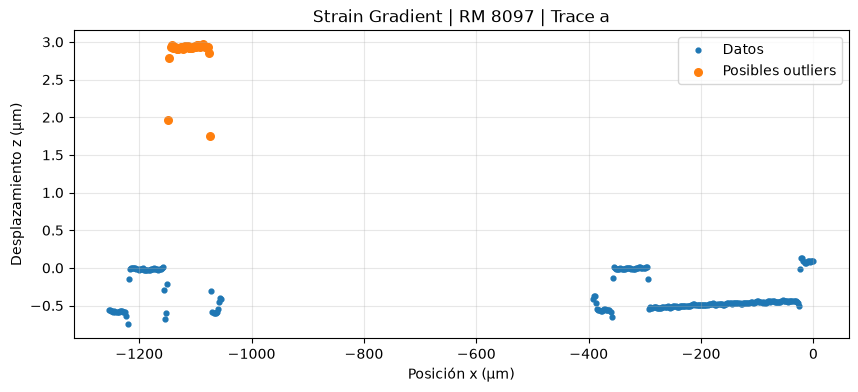

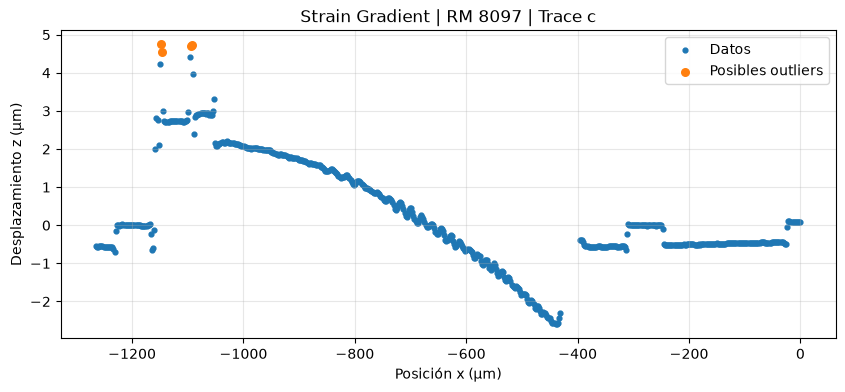

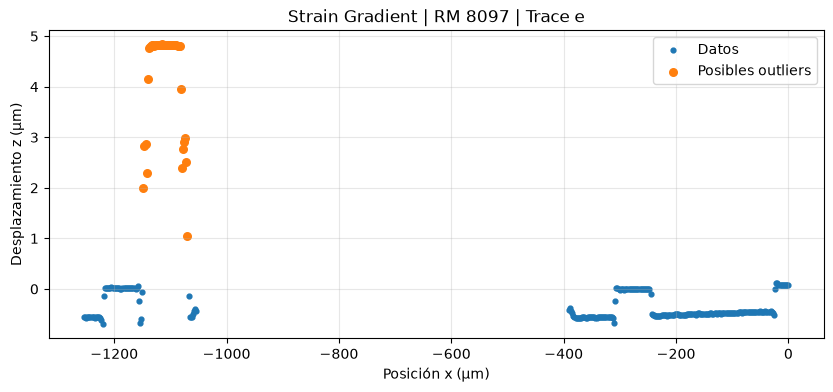

In [19]:
for keys, group in df_master.groupby(
    ["test_type", "material", "trace"]
):
    test_type, material, trace = keys

    q1 = group["z"].quantile(0.25)
    q3 = group["z"].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (group["z"] < lower_bound)
        | (group["z"] > upper_bound)
    )

    plt.figure(figsize=(10, 4))

    plt.scatter(
        group["x"],
        group["z"],
        s=12,
        label="Datos",
    )

    plt.scatter(
        group.loc[mask, "x"],
        group.loc[mask, "z"],
        s=30,
        label="Posibles outliers",
    )

    plt.title(f"{test_type} | {material} | Trace {trace}")
    plt.xlabel("Posición x (µm)")
    plt.ylabel("Desplazamiento z (µm)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

### Tratamiento de valores atípicos

La regla del rango intercuartílico (IQR) identificó 283 observaciones como
potencialmente atípicas. Sin embargo, la inspección gráfica por traza muestra
que una parte importante de estas observaciones pertenece a segmentos
estructurados y continuos de los perfiles experimentales, en lugar de
corresponder a valores aislados.

El método IQR analiza únicamente la distribución de `z` y no considera la
posición espacial `x` ni la continuidad de cada perfil. Por ello, una
observación estadísticamente extrema no implica necesariamente un error de
medición en este conjunto de datos.

En consecuencia, los valores identificados mediante IQR se conservan para el
análisis. Eliminarlos podría remover características físicamente relevantes
de las trazas. El IQR se utiliza en este análisis como herramienta de
detección y no como criterio automático de eliminación.

### Valores faltantes

In [20]:
missing_summary = pd.DataFrame({
    "missing_values": df_master.isna().sum(),
    "missing_percentage": (
        df_master.isna().mean() * 100
    ),
})

display(missing_summary)

,missing_values,missing_percentage
test_type,0,0.0000
structure,0,0.0000
material,0,0.0000
chip,0,0.0000
length_um,0,0.0000
trace,0,0.0000
x,0,0.0000
z,0,0.0000
calibrated,0,0.0000
file,0,0.0000


### Tratamiento de valores faltantes

Los archivos originales de NIST contienen, además de las mediciones,
encabezados, fórmulas, instrucciones y otras celdas auxiliares. Durante la
construcción del conjunto de datos se convirtieron las columnas de medición
a valores numéricos y se conservaron únicamente las filas que contienen un
par válido de coordenadas `(x, z)`.

Por esta razón, el conjunto consolidado utilizado para el EDA no presenta
valores faltantes en las variables analizadas. No se realizó imputación, ya
que las filas descartadas no corresponden necesariamente a mediciones
experimentales ausentes, sino principalmente a la estructura adicional de
los archivos Excel.

### Alta cardinalidad

In [21]:
cardinality = (
    df_master[
        ["test_type", "material", "trace", "file"]
    ]
    .nunique()
    .rename("unique_values")
    .to_frame()
)

display(cardinality)

,unique_values
test_type,2
material,2
trace,6
file,10


No se identificó un problema de alta cardinalidad en las variables
categóricas. `test_type` y `material` contienen 2 categorías cada una,
mientras que `trace` contiene 6 categorías.

La variable `file` presenta 10 valores únicos, correspondientes a los 10
archivos de origen, y se conserva únicamente con fines de trazabilidad.

Por lo tanto, no es necesario aplicar técnicas de agrupamiento, reducción
de categorías o codificación especial para mitigar alta cardinalidad.

## 3. Análisis bi/multivariante

En esta sección se analiza la relación entre la posición `x` y el
desplazamiento `z`. Debido a que las observaciones pertenecen a diferentes
materiales, tipos de ensayo y trazas, la relación se estudia tanto de forma
global como por grupo.

Se emplean visualizaciones de los perfiles experimentales y coeficientes de
correlación para evaluar las relaciones entre las variables cuantitativas.

### Visual de las trazas de forma individual

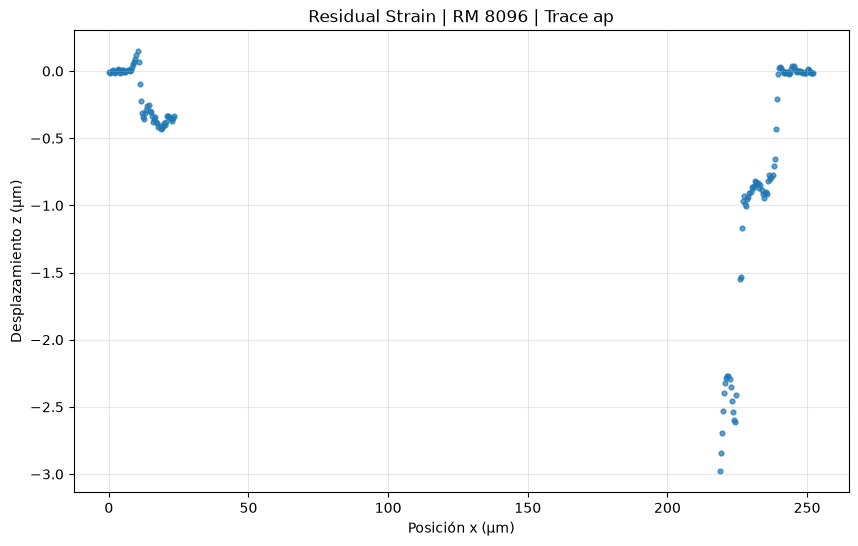

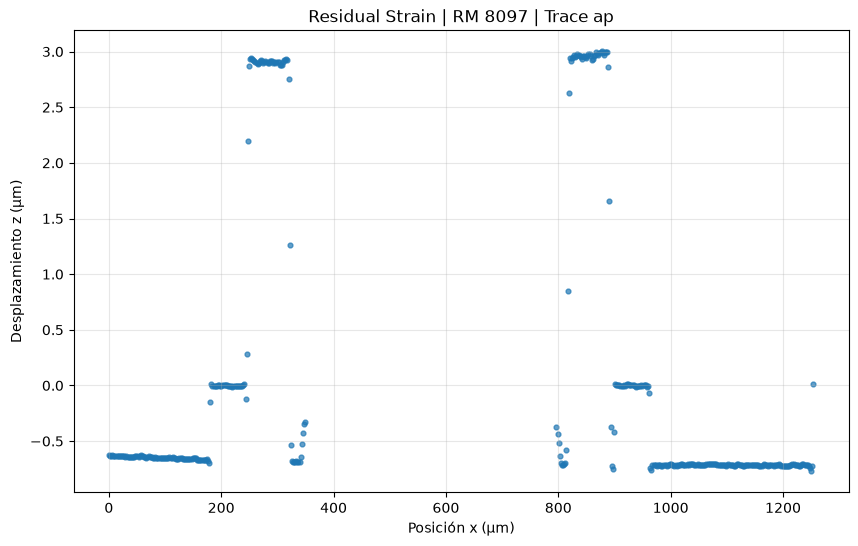

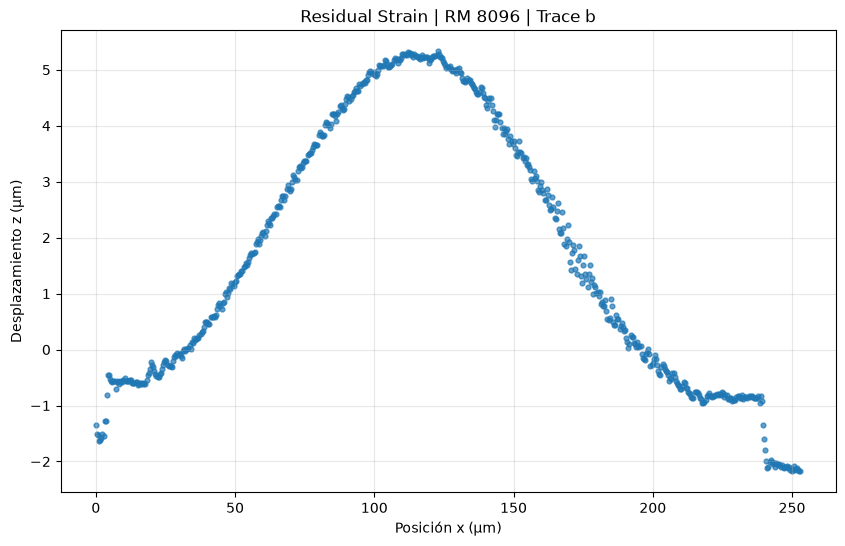

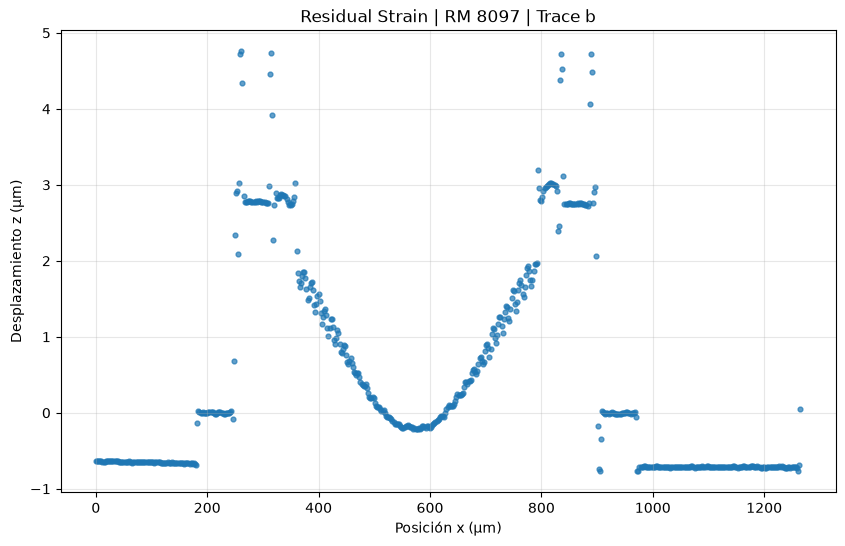

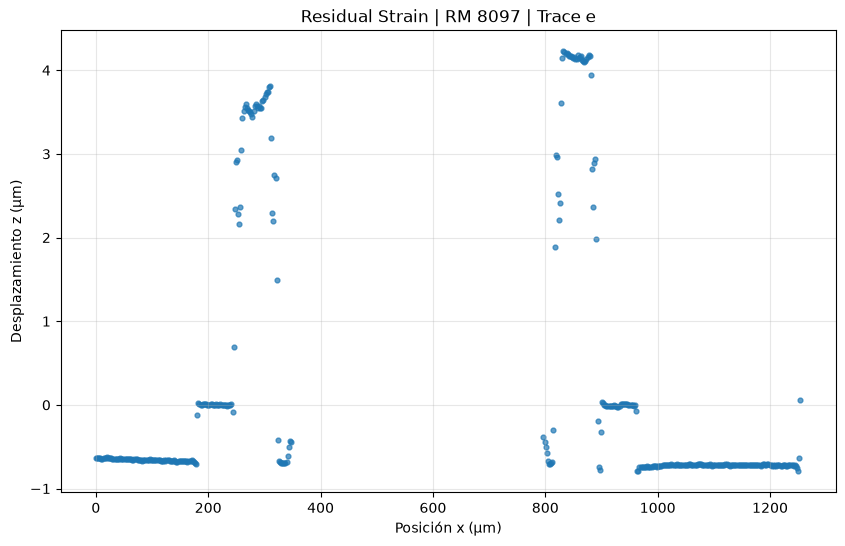

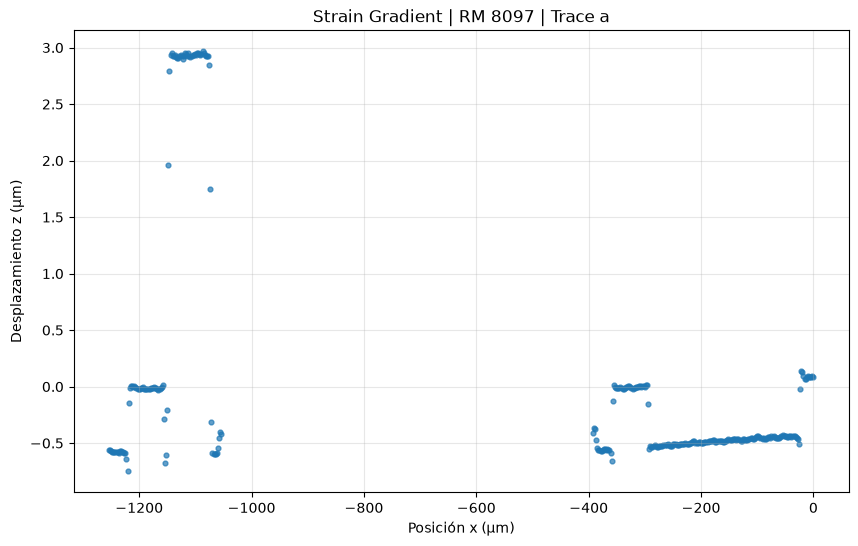

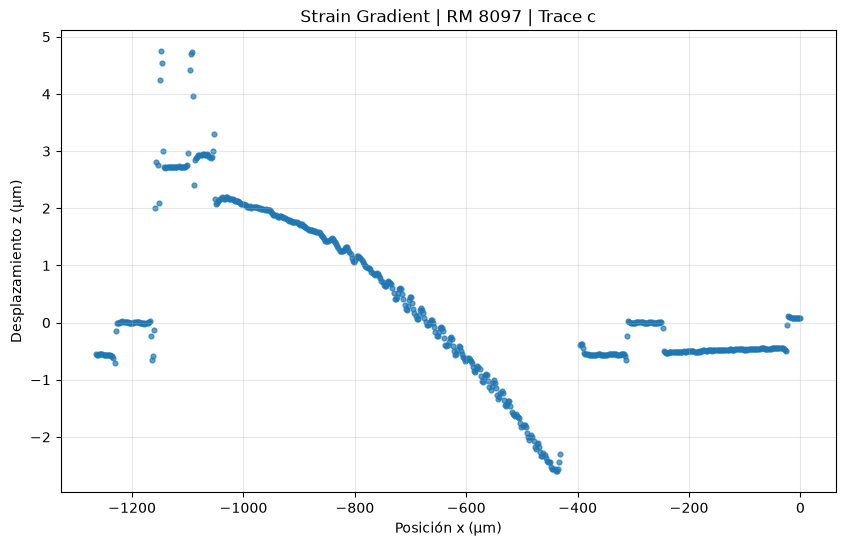

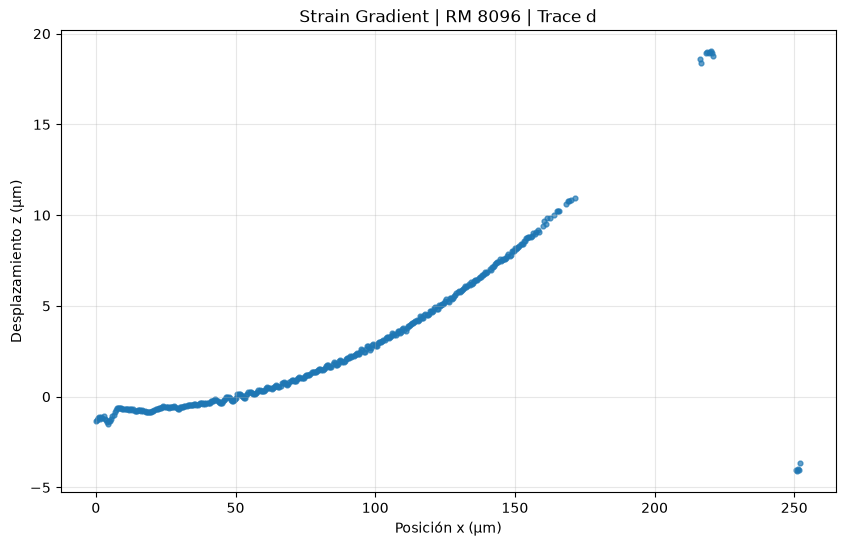

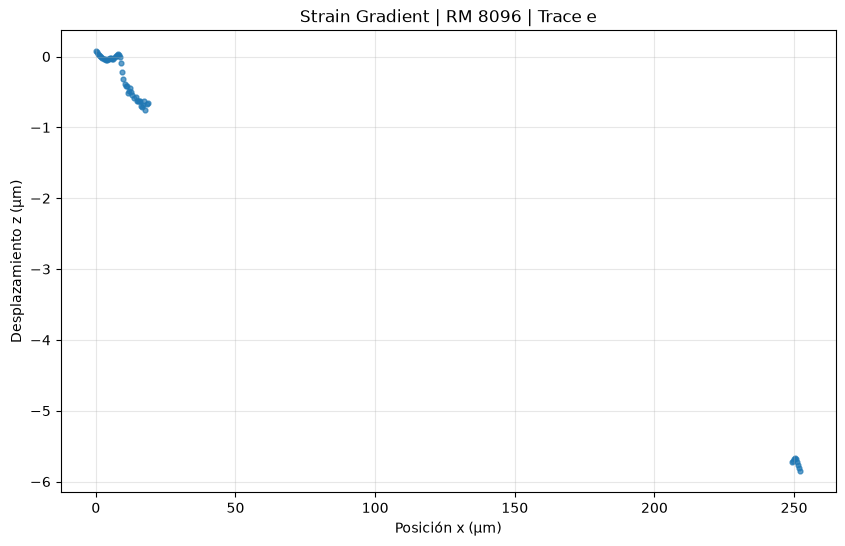

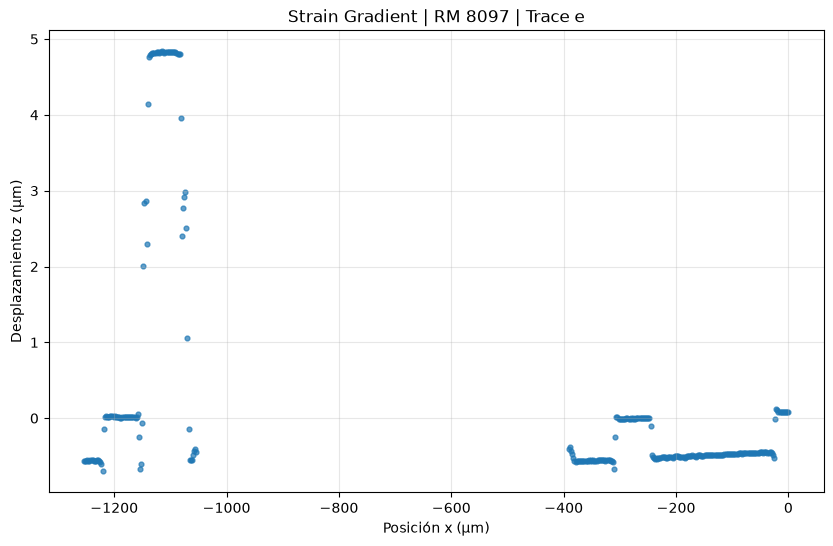

In [22]:
groups = df_master.groupby(
    ["test_type", "material", "trace"],
    sort=False,
)

for keys, group in groups:
    test_type, material, trace = keys

    group = group.sort_values("x")

    plt.figure(figsize=FIGSIZE)

    plt.scatter(
        group["x"],
        group["z"],
        s=12,
        alpha=0.7,
    )

    plt.title(f"{test_type} | {material} | Trace {trace}")
    plt.xlabel("Posición x (µm)")
    plt.ylabel("Desplazamiento z (µm)")
    plt.grid(alpha=0.3)

    plt.show()

### Correlación global y por traza

In [23]:
global_correlation = df_master["x"].corr(df_master["z"])

print(
    "Correlación global de Pearson entre x y z: "
    f"{global_correlation:.4f}"
)

correlation_by_trace = (
    df_master
    .groupby(
        ["test_type", "material", "trace"],
    )
    .apply(
        lambda group: group["x"].corr(group["z"]),
        include_groups=False,
    )
    .rename("pearson_correlation")
    .reset_index()
)

display(correlation_by_trace)

Correlación global de Pearson entre x y z: -0.0752


,test_type,material,trace,pearson_correlation
0,Residual Strain,RM 8096,ap,-0.3734
1,Residual Strain,RM 8096,b,-0.2350
2,Residual Strain,RM 8097,ap,-0.1298
3,Residual Strain,RM 8097,b,-0.1472
4,Residual Strain,RM 8097,e,-0.1077
5,Strain Gradient,RM 8096,d,0.8139
6,Strain Gradient,RM 8096,e,-0.9967
7,Strain Gradient,RM 8097,a,-0.5060
8,Strain Gradient,RM 8097,c,-0.6086
9,Strain Gradient,RM 8097,e,-0.5080


#### Interpretación de la correlación

La correlación global de Pearson entre `x` y `z` es -0.0752, lo que sugiere
una relación lineal prácticamente nula al considerar todas las observaciones
como un único conjunto.

Sin embargo, este resultado global oculta diferencias importantes entre las
trazas. Al calcular la correlación de manera independiente, se observan
relaciones de distinta magnitud y dirección. Por ejemplo, Strain Gradient
RM 8096, traza d, presenta una correlación positiva fuerte (0.8139), mientras
que la traza e del mismo material presenta una correlación negativa muy fuerte
(-0.9967).

Las trazas de Residual Strain presentan coeficientes de Pearson de menor
magnitud. No obstante, las visualizaciones muestran perfiles curvos, por lo
que un coeficiente lineal bajo no implica necesariamente ausencia de relación
entre la posición y el desplazamiento.

Por esta razón, la relación entre `x` y `z` debe interpretarse conjuntamente
mediante los coeficientes de correlación y la inspección gráfica de cada
traza, evitando conclusiones basadas únicamente en la correlación global.

In [24]:
correlation_comparison = (
    df_master
    .groupby(
        ["test_type", "material", "trace"],
    )
    .apply(
        lambda group: pd.Series({
            "pearson": group["x"].corr(
                group["z"],
                method="pearson",
            ),
            "spearman": group["x"].corr(
                group["z"],
                method="spearman",
            ),
        }),
        include_groups=False,
    )
    .reset_index()
)

display(correlation_comparison)

,test_type,material,trace,pearson,spearman
0,Residual Strain,RM 8096,ap,-0.3734,-0.0984
1,Residual Strain,RM 8096,b,-0.2350,-0.2767
2,Residual Strain,RM 8097,ap,-0.1298,-0.5371
3,Residual Strain,RM 8097,b,-0.1472,-0.3411
4,Residual Strain,RM 8097,e,-0.1077,-0.5307
5,Strain Gradient,RM 8096,d,0.8139,0.9287
6,Strain Gradient,RM 8096,e,-0.9967,-0.9336
7,Strain Gradient,RM 8097,a,-0.5060,-0.0917
8,Strain Gradient,RM 8097,c,-0.6086,-0.5643
9,Strain Gradient,RM 8097,e,-0.5080,-0.1076


#### Comparación entre Pearson y Spearman

La comparación entre los coeficientes de Pearson y Spearman confirma que la
relación entre posición y desplazamiento depende de la traza y no siempre
puede describirse adecuadamente mediante una relación lineal.

En Strain Gradient RM 8096, las trazas d y e presentan asociaciones fuertes
con ambos coeficientes. La traza d muestra una relación positiva fuerte
(Pearson = 0.8139; Spearman = 0.9287), mientras que la traza e presenta una
relación negativa muy fuerte (Pearson = -0.9967; Spearman = -0.9336).

En otras trazas existen diferencias importantes entre ambos coeficientes. Por
ejemplo, Residual Strain RM 8097, traza ap, presenta Pearson = -0.1298 y
Spearman = -0.5371. Esto indica que una relación poco lineal puede presentar
una asociación monotónica de mayor magnitud.

También existen perfiles en los que ninguno de los coeficientes resume por
completo la geometría observada. Por ello, los coeficientes se interpretan
como medidas complementarias a las visualizaciones de las trazas y no como
evidencia suficiente, por sí solos, de ausencia o presencia de una relación
entre `x` y `z`.

### Comparación de categorías

In [25]:
category_summary = (
    df_master
    .groupby(
        ["test_type", "material"],
        as_index=False,
    )
    .agg(
        observations=("z", "size"),
        z_mean=("z", "mean"),
        z_median=("z", "median"),
        z_std=("z", "std"),
        z_min=("z", "min"),
        z_max=("z", "max"),
    )
)

display(category_summary)

,test_type,material,observations,z_mean,z_median,z_std,z_min,z_max
0,Residual Strain,RM 8096,784,1.2469,0.2079,2.3088,-2.9809,5.3275
1,Residual Strain,RM 8097,1465,0.2959,-0.6334,1.4481,-0.7961,4.7550
2,Strain Gradient,RM 8096,483,2.3748,0.9182,4.0758,-5.8574,19.0176
3,Strain Gradient,RM 8097,1230,0.2378,-0.4388,1.3903,-2.6045,4.8358


### Distribución de z por tipo de ensayo

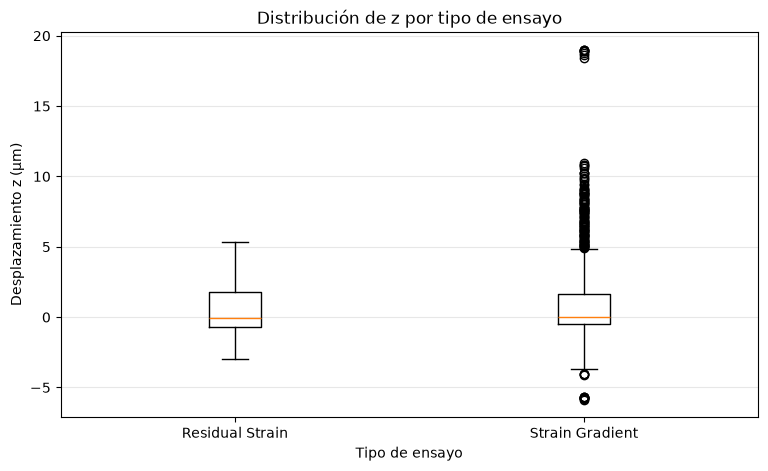

In [26]:
test_types = df_master["test_type"].unique()

data_by_test = [
    df_master.loc[
        df_master["test_type"] == test_type,
        "z",
    ]
    for test_type in test_types
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    data_by_test,
    tick_labels=test_types,
)

plt.title("Distribución de z por tipo de ensayo")
plt.xlabel("Tipo de ensayo")
plt.ylabel("Desplazamiento z (µm)")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Por material

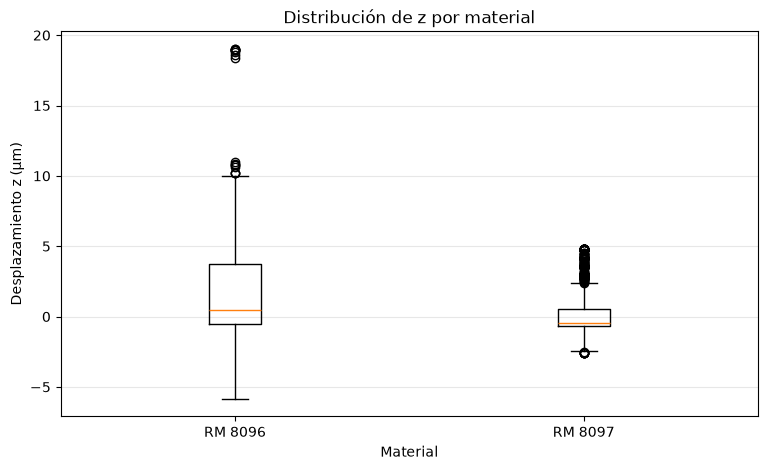

In [27]:
materials = df_master["material"].unique()

data_by_material = [
    df_master.loc[
        df_master["material"] == material,
        "z",
    ]
    for material in materials
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    data_by_material,
    tick_labels=materials,
)

plt.title("Distribución de z por material")
plt.xlabel("Material")
plt.ylabel("Desplazamiento z (µm)")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Comparación por tipo de ensayo y material

La distribución del desplazamiento `z` presenta diferencias importantes entre
los grupos analizados. RM 8096 muestra, en general, una mayor dispersión que
RM 8097.

Esta diferencia es especialmente evidente en Strain Gradient. Para RM 8096,
`z` presenta una media de 2.3748 µm, una desviación estándar de 4.0758 µm y
valores entre -5.8574 y 19.0176 µm. Para RM 8097, la media es de 0.2378 µm,
la desviación estándar de 1.3903 µm y el intervalo observado se encuentra
entre -2.6045 y 4.8358 µm.

En Residual Strain también se observa mayor variabilidad en RM 8096
(desviación estándar de 2.3088 µm) que en RM 8097 (1.4481 µm).

Los diagramas de caja confirman estas diferencias y muestran nuevamente
observaciones estadísticamente extremas. Como se discutió previamente, estos
valores se conservan debido a que pueden formar parte de la estructura de los
perfiles experimentales.

Estas comparaciones son descriptivas y no se interpretan como evidencia de
que un material presente un comportamiento superior a otro, ya que las
observaciones provienen de diferentes trazas y condiciones experimentales.

Además, estas comparaciones mezclan varios factores a la vez: el material (óxido en RM 8096 y polisilicio en RM 8097), la longitud de la estructura (200 µm contra 500–650 µm), el tipo de estructura (viga biempotrada o voladizo) y el tipo de traza (a lo largo de la viga o transversal). Por eso no se usan para sacar conclusiones físicas. El análisis físico, estructura por estructura, está en la sección 5.

## 4. Aspectos del EDA que no aplican al conjunto de datos

### Tendencias temporales

No aplica un análisis de tendencias temporales. Las variables principales
representan posición (`x`) y desplazamiento (`z`) a lo largo de perfiles
espaciales. Aunque los archivos puedan contener metadatos relacionados con
su adquisición, el conjunto consolidado utilizado en este análisis no
representa una serie temporal.

### Desbalance de clases

No aplica un análisis de desbalance de la variable objetivo, ya que este
avance corresponde a un análisis exploratorio de mediciones continuas y no
se ha definido una variable objetivo categórica para un problema de
clasificación.

### Normalización de imágenes

No aplica normalización de imágenes, debido a que el conjunto analizado está
compuesto por mediciones numéricas obtenidas de archivos Excel y no contiene
datos de imagen.

### Transformaciones no lineales

Aunque la variable `z` presenta asimetría positiva, no se aplica una
transformación no lineal en este avance. Los valores representan
desplazamientos físicos y pueden incluir valores positivos, negativos y
cercanos a cero. Además, las diferencias en la distribución están asociadas
a la geometría de las distintas trazas. Una transformación podría dificultar
su interpretación física sin aportar un beneficio claro para los objetivos
del EDA.

## 5. Análisis por perfil para el Brazo 2

Las secciones anteriores siguen el formato del EDA del curso y analizan `x` y `z` con todas las trazas juntas. Para el proyecto, el Brazo 2 necesita otra cosa: estimar la **deformación residual** en las vigas biempotradas y el **gradiente de deformación** en los voladizos, y revisar si los residuos del modelo tienen **estructura espacial**, en particular cerca del anclaje (guía `datos/02-datos-reales-nist-sp260-177.md`, §6).

Esta sección analiza por separado las cuatro estructuras que tienen una traza a lo largo de la viga (trazas b, c y d). Usa el tramo de la viga y el modelo que calcula la propia hoja del NIST: dos cosenos para la viga biempotrada y un círculo para el voladizo. La conversión de las trazas está validada contra esas mismas hojas (`tests/test_brazo2.py`). Las trazas transversales (a, a', e) sirven para ubicar los bordes de la estructura y no se modelan.

In [28]:
from pinn_mems.nist.brazo2 import beam_profile, read_sheet_parameters, residual_by_zone, strain_gradient
from pinn_mems.nist.ruido import noise_table

beam_files = [f for f in excel_files if f.name.split(".Trace.")[1].split(".")[0] in {"b", "c", "d"}]
profiles = {f.name: beam_profile(f) for f in beam_files}

structures = []
for f in beam_files:
    profile = profiles[f.name]
    params = read_sheet_parameters(f)
    structures.append({
        "structure": profile["structure"].iloc[0],
        "material": profile["material"].iloc[0],
        "length_um": profile["length_um"].iloc[0],
        "trace": profile["trace"].iloc[0],
        "modeled_points": len(profile),
        "v_start_um": profile["v_um"].iloc[0],
        "v_end_um": profile["v_um"].iloc[-1],
        "Rint_um": params.get("Rint", np.nan),
        "strain_gradient_1_per_m": strain_gradient(params["Rint"], params["s"]) if "Rint" in params else np.nan,
    })

structures = pd.DataFrame(structures)
display(structures)

,structure,material,length_um,trace,modeled_points,v_start_um,v_end_um,Rint_um,strain_gradient_1_per_m
0,fixed-fixed,RM 8096,200,b,492,26.1314,220.5319,NaN,NaN
1,fixed-fixed,RM 8097,500,b,252,320.7052,817.6002,NaN,NaN
2,cantilever,RM 8097,650,c,322,-439.8196,-1074.9637,47523.6500,-21.0422
3,cantilever,RM 8096,200,d,342,21.3802,157.1842,1171.9800,853.2569


### 5.1 Las cuatro estructuras

- En los **voladizos**, el NIST describe el perfil con un círculo de radio `Rint`; el gradiente de deformación es `1/Rint` (con el signo de la curvatura). Para el voladizo de RM 8096 se obtiene el mismo valor que el ejemplo resuelto del SP 260-177 (853 m⁻¹, p. 190).
- En las **vigas biempotradas**, la deformación residual requiere el procedimiento completo de la norma ASTM E2245 (longitud curva de los dos cosenos y longitud en el plano a partir de los bordes). El cálculo ya está implementado y validado con el ejemplo resuelto del NIST (`brazo2.residual_strain`), pero aplicarlo a estas trazas requiere elegir los cinco puntos y los bordes de cada viga; por eso aquí solo se analiza la forma del perfil.
- `v` es la posición a lo largo de la viga corregida por la desalineación α; en los voladizos con orientación de 180° es negativa.

### 5.2 Perfil medido contra el modelo del NIST

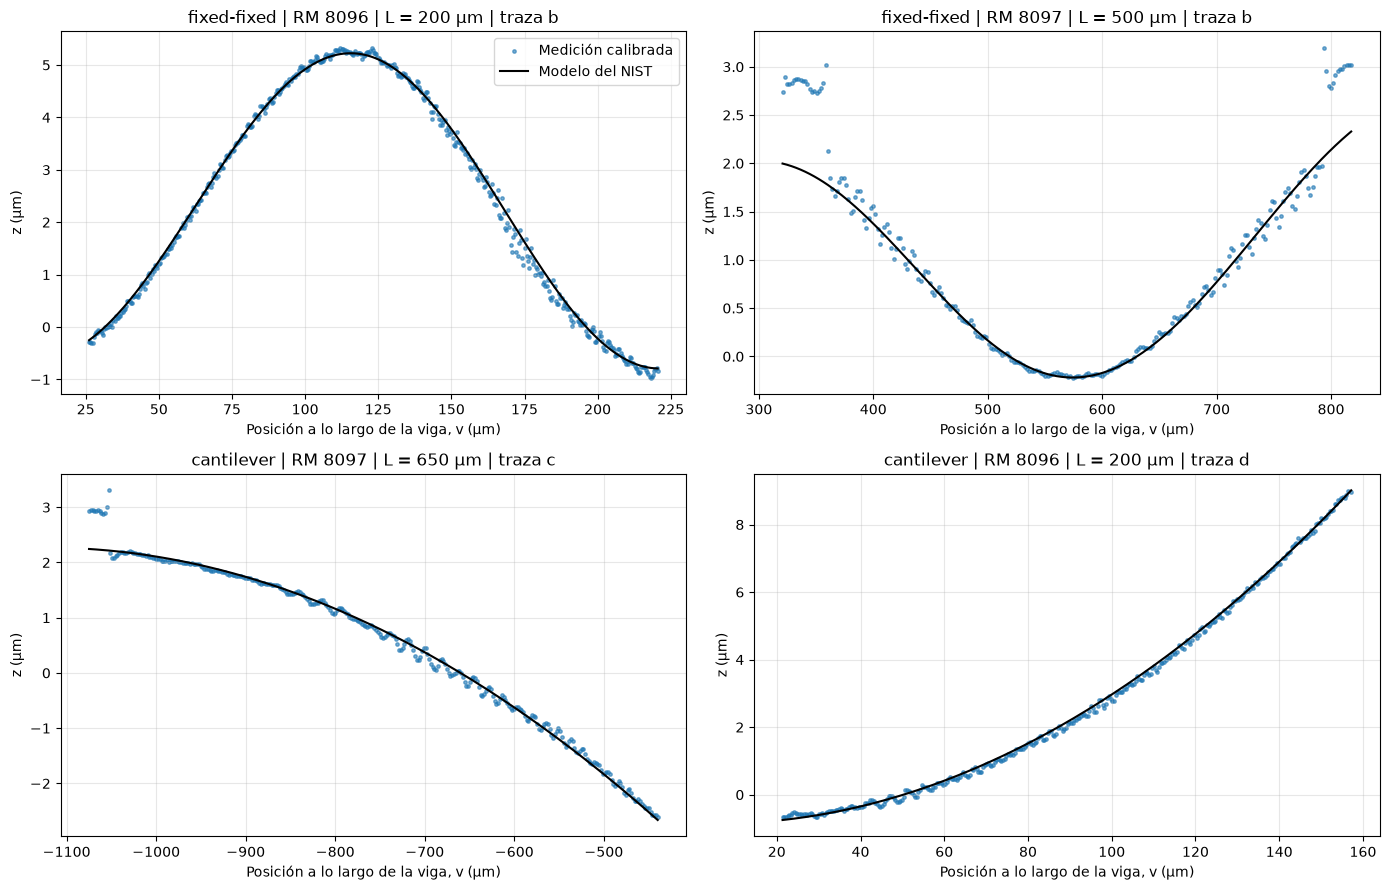

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, f in zip(axes.flat, beam_files):
    profile = profiles[f.name]
    ax.scatter(profile["v_um"], profile["z_um"], s=6, alpha=0.6, label="Medición calibrada")
    ax.plot(profile["v_um"], profile["z_model_um"], color="black", linewidth=1.5, label="Modelo del NIST")
    ax.set_title(f"{profile['structure'].iloc[0]} | {profile['material'].iloc[0]} | "
                 f"L = {profile['length_um'].iloc[0]} µm | traza {profile['trace'].iloc[0]}")
    ax.set_xlabel("Posición a lo largo de la viga, v (µm)")
    ax.set_ylabel("z (µm)")
    ax.grid(alpha=0.3)

axes[0, 0].legend()
plt.tight_layout()
plt.show()

A simple vista el modelo describe bien la forma de cada estructura: el arco de las vigas biempotradas y la curvatura de los voladizos. Para ver dónde falla hay que mirar los residuos.

### 5.3 Residuos y ruido de medición

El residuo es la medición menos el modelo. La franja gris marca ±2σ del ruido de medición, estimado en cada traza con segundas diferencias (`src/pinn_mems/nist/ruido.py`). La posición se normaliza con `xi`, que va de 0 en el borde del anclaje (el offset `f` de la hoja) a 1 a lo largo del tramo que modela el NIST.

En las estructuras de RM 8097, el tramo del NIST incluye en sus extremos algunos puntos sobre la **meseta del soporte**, casi 1 µm por encima de la viga. Ahí el modelo de la viga no aplica, así que esos puntos (en gris claro) se excluyen de los cálculos de residuos (`on_beam = False`).

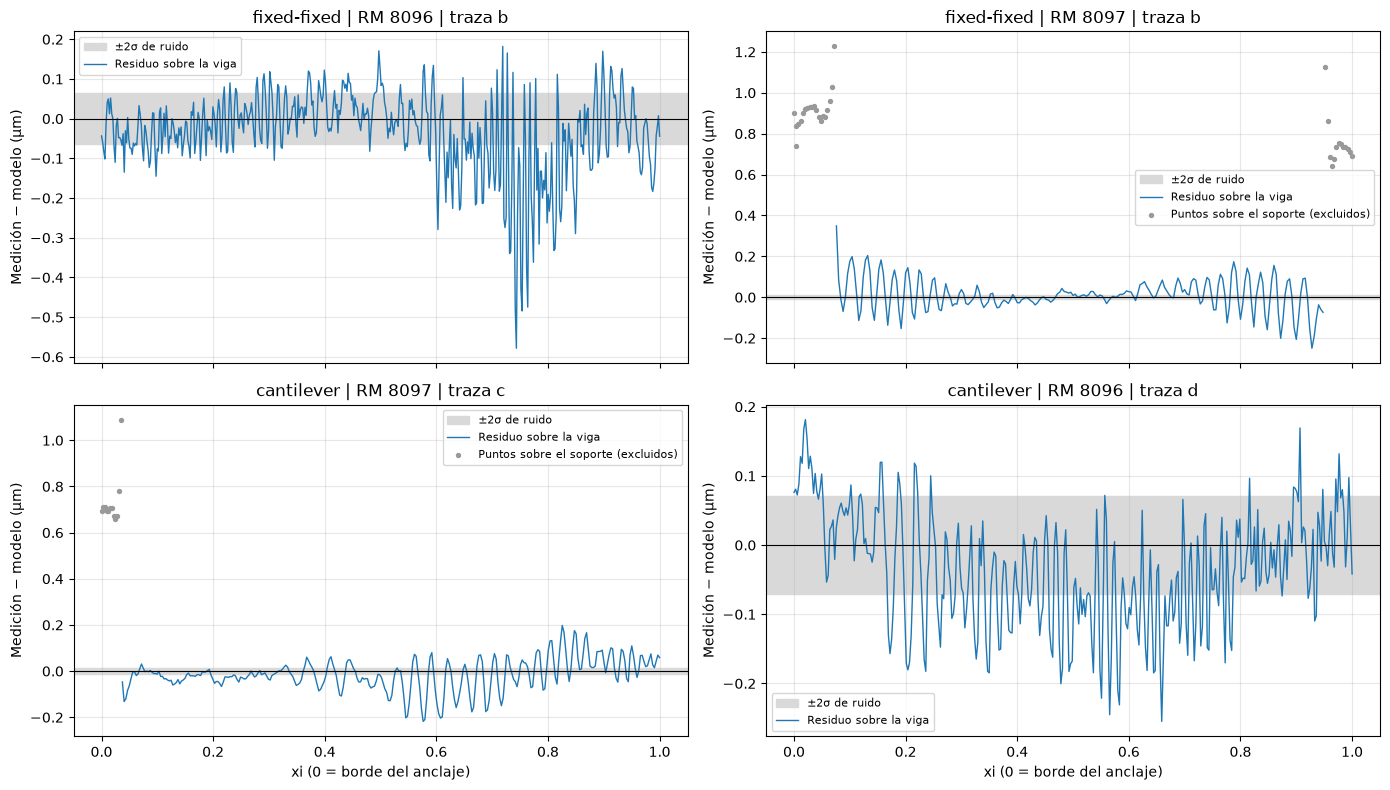

In [30]:
noise = noise_table().set_index("file")

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, f in zip(axes.flat, beam_files):
    profile = profiles[f.name]
    beam = profile[profile["on_beam"]]
    support = profile[~profile["on_beam"]]
    sigma = noise.loc[f.name, "sigma_second_diff_um"]
    ax.axhspan(-2 * sigma, 2 * sigma, color="0.85", label="±2σ de ruido")
    ax.plot(beam["xi"], beam["residual_um"], linewidth=1, label="Residuo sobre la viga")
    if len(support):
        ax.scatter(support["xi"], support["residual_um"], s=8, color="0.6", label="Puntos sobre el soporte (excluidos)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{profile['structure'].iloc[0]} | {profile['material'].iloc[0]} | traza {profile['trace'].iloc[0]}")
    ax.set_ylabel("Medición − modelo (µm)")
    ax.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("xi (0 = borde del anclaje)")
for ax in axes.flat:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [31]:
zones = []
for f in beam_files:
    profile = profiles[f.name]
    sigma = noise.loc[f.name, "sigma_second_diff_um"]
    summary = residual_by_zone(profile)
    zones.append({
        "structure": profile["structure"].iloc[0],
        "material": profile["material"].iloc[0],
        "trace": profile["trace"].iloc[0],
        "noise_sigma_um": sigma,
        **summary,
        "excluded_points": int((~profile["on_beam"]).sum()),
        "rms_total_over_noise": np.sqrt(np.mean(profile.loc[profile["on_beam"], "residual_um"] ** 2)) / sigma,
    })

zones = pd.DataFrame(zones)
display(zones)

,structure,material,trace,noise_sigma_um,rms_start_um,rms_center_um,rms_end_um,lag1_autocorrelation,excluded_points,rms_total_over_noise
0,fixed-fixed,RM 8096,b,0.0318,0.0608,0.1230,0.0864,0.6152,0,3.4793
1,fixed-fixed,RM 8097,b,0.0048,0.1397,0.0612,0.1193,0.5982,33,16.4525
2,cantilever,RM 8097,c,0.0063,0.0447,0.0740,0.0684,0.8156,12,11.1318
3,cantilever,RM 8096,d,0.0355,0.0746,0.0992,0.0592,0.6799,0,2.5627


### 5.4 Lectura de los residuos

Los números de esta sección se calculan solo con los puntos sobre la viga.

- **Los residuos tienen estructura, no son ruido.** En las cuatro estructuras el residuo es entre 2.6 y 16.5 veces el ruido de medición (`rms_total_over_noise`) y está correlacionado entre puntos vecinos (`lag1_autocorrelation` entre 0.6 y 0.8; con ruido blanco sería cercana a 0). El modelo del NIST deja una parte sistemática sin explicar: exactamente el tipo de discrepancia que estudia el proyecto.
- **Viga biempotrada de RM 8097:** cerca de los dos soportes el residuo es unas dos veces el del centro (`rms_start_um` y `rms_end_um` contra `rms_center_um`). Es una firma "cerca del anclaje" como la que busca el Brazo 2. Pero el SP 260-177 advierte que en RM 8097 hay transiciones verticales de la geometría cerca de los soportes, así que no se puede atribuir solo a la flexibilidad del anclaje.
- **Voladizo de RM 8097 y estructuras de RM 8096 (óxido):** no muestran una firma cerca del anclaje; en RM 8096 el residuo es algo mayor en el centro de la viga.
- **Oscilación regular en RM 8097:** en las dos estructuras de polisilicio el residuo oscila con un periodo casi constante (unos pocos puntos de muestreo) y su amplitud crece hacia los extremos. Podría ser un artefacto del interferómetro más que una propiedad de la viga; conviene revisarlo antes de usar estos residuos para comparar métodos.
- **Ojo con el tramo de la hoja:** en RM 8097 el tramo que modela el NIST incluye puntos sobre el soporte. Si no se excluyen, aparentan un residuo diez veces mayor cerca de los extremos.
- **Consecuencia para el modelado:** como los residuos están correlacionados, una verosimilitud que trate cada punto como independiente subestimaría la incertidumbre. Conviene un modelo de discrepancia o de ruido correlacionado (niveles L2 y L3 de la escalera).

### 5.5 Tendencias con la longitud y alcance del Brazo 2

El SP 260-177 resume la dependencia con la longitud en dos figuras que no forman parte de estos archivos:

- **Fig. RS10 (deformación residual):** "reveals no obvious length dependence" [SP 260-177, p. 72]. Es un resultado nulo.
- **Fig. SG10 (gradiente de deformación):** el gradiente baja al aumentar la longitud de 400 a 600 µm y luego se estabiliza entre 600 y 750 µm [SP 260-177, p. 92]. Es una tendencia, pero no necesariamente causada por el anclaje.

Alcance de estos datos:

- Son **cuatro estructuras de ejemplo**, de dos materiales (óxido y polisilicio) y con **una sola traza a lo largo de cada una**. No forman un barrido de longitudes.
- Los brazos **no miden los mismos chips**: no se compara el ΔL del Brazo 1 con estos datos.
- Sí permiten lo que el Brazo 1 no puede: probar los métodos con **residuos espaciales reales**, medidos a lo largo de la viga.

## 6. Conclusiones

El análisis exploratorio permitió caracterizar las mediciones de Residual
Strain y Strain Gradient correspondientes a los materiales de referencia
RM 8096 y RM 8097. El conjunto consolidado contiene 3,962 observaciones
provenientes de 10 trazas experimentales.

La exploración mostró que las trazas presentan comportamientos heterogéneos,
por lo que analizarlas únicamente como un conjunto agregado puede ocultar
información relevante. Esto se observa especialmente en la relación entre
posición (`x`) y desplazamiento (`z`): la correlación global de Pearson fue
de -0.0752, lo que inicialmente sugeriría una relación lineal prácticamente
nula. Sin embargo, el análisis individual reveló relaciones considerablemente
más fuertes. Por ejemplo, Strain Gradient RM 8096, traza d, presentó una
correlación de Pearson de 0.8139, mientras que la traza e alcanzó -0.9967.

La comparación entre Pearson y Spearman también mostró que algunas relaciones
no pueden describirse adecuadamente mediante una asociación lineal. Los
perfiles experimentales presentan formas y cambios de dirección que hacen
necesario complementar las métricas de correlación con la inspección gráfica
de cada traza.

En el análisis univariante, `z` presentó una asimetría positiva considerable
(skewness = 2.3442), mientras que `x` mostró una asimetría global ligera
(skewness = -0.2301). La distribución de `x` es multimodal debido a la
combinación de perfiles con diferentes rangos espaciales y orientaciones,
por lo que no se consideró apropiado tratarla como una única distribución.

Mediante la regla del rango intercuartílico (IQR) se identificaron 283
observaciones potencialmente atípicas. La inspección de las trazas mostró
que una parte importante de estos valores pertenece a regiones continuas de
los perfiles y no corresponde a observaciones aisladas. Por esta razón, se
decidió conservarlos, ya que su eliminación podría remover información
físicamente relevante de las mediciones.

También se observaron diferencias entre los materiales y tipos de ensayo.
RM 8096 presentó una mayor variabilidad de `z` que RM 8097. Esta diferencia
fue especialmente evidente en Strain Gradient, donde RM 8096 presentó una
desviación estándar de 4.0758 µm frente a 1.3903 µm para RM 8097. Estas
diferencias se consideran descriptivas y no implican por sí mismas un mejor
o peor comportamiento de alguno de los materiales.

Durante el preprocesamiento se aplicaron los factores de calibración del
instrumento a las trazas que los incluyen (b, c y d), se homogeneizaron las
mediciones de posición en micrómetros y se conservaron únicamente pares numéricos válidos de `(x, z)`.
El conjunto consolidado resultante no presenta valores faltantes en las
variables analizadas. Tampoco se identificó un problema de alta cardinalidad
en las variables categóricas.

En conjunto, el EDA muestra que la estructura espacial y la pertenencia a
cada traza son fundamentales para interpretar correctamente las mediciones.
Por ello, análisis posteriores deberían conservar la separación entre tipos
de ensayo, materiales y trazas, evitando depender únicamente de estadísticas
globales que pueden ocultar patrones locales relevantes.

El análisis por perfil de la sección 5 agrega lo que el Brazo 2 necesita para el proyecto. Al comparar cada estructura con el modelo que ajusta el propio NIST, los residuos resultan mayores que el ruido de medición y fuertemente correlacionados: el modelo deja una parte sistemática sin explicar. En la viga biempotrada de RM 8097 la discrepancia es mayor cerca de los soportes, aunque ahí también hay transiciones de geometría; además, el tramo de la hoja incluye puntos sobre el soporte que deben excluirse. Estos datos no sirven para un barrido de longitudes ni para comparar el ΔL con el Brazo 1, pero sí para probar los métodos con residuos espaciales reales.